In [2]:
# cell 1
!pip install pandas numpy matplotlib seaborn scikit-learn plotly openpyxl --upgrade pip
print("All libraries installed successfully!")

  Using cached pandas-2.3.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.3.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.6-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
Using cached pandas-2.3.2-cp313-cp313-win_amd64.whl (11.0 MB)
Using cached numpy-2.3.3-cp313-cp313-win_amd64.whl (12.8 MB)
Using cached matplotlib-3.10.6-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl (8.7 MB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
All libraries installed successfully!



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\Hp\AppData\Local\Programs\Python\Python313\python.exe -m pip install pandas numpy matplotlib seaborn scikit-learn plotly openpyxl --upgrade pip


In [3]:
#cell 2
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('default')

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.2.4


In [5]:
# Cell 3: Load and preprocess CDR data from Excel
try:
    df = pd.read_excel('ICalls dataset.xlsx', engine='openpyxl', sheet_name=0)
    print("✅ Successfully loaded ICalls dataset.xlsx")
    
    # Drop unneeded subscriber ID columns
    cols_to_drop = ['CALLING_NUMBER_NOR', 'CALLED_NUMBER_NOR']
    existing_drops = [c for c in cols_to_drop if c in df.columns]
    if existing_drops:
        df.drop(columns=existing_drops, inplace=True)
        print(f"ℹ️ Dropped columns: {existing_drops}")
    
    # Display basic dataset information
    print("\n=== DATASET INFORMATION ===")
    print(f"Shape after drop: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Verify required columns
    required_columns = [
        'CALL_ID', 'START_TIMESTAMP', 'CALL_DURATION_SEC',
        'ANSWERED', 'COST', 'REVENUE'
    ]
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"⚠️ Missing required columns: {missing_columns}")
        print("Available columns:", list(df.columns))
    else:
        print("✅ All required columns found")
    
    # Convert timestamp column to datetime
    df['START_TIMESTAMP'] = pd.to_datetime(df['START_TIMESTAMP'])
    print(f"Date range: {df['START_TIMESTAMP'].min()} to {df['START_TIMESTAMP'].max()}")
    
    # Display unique switches if present
    if 'IN_SWITCH_ID' in df.columns:
        print(f"Unique switches: {df['IN_SWITCH_ID'].nunique()}")
    
    # Check for missing values
    print("\n=== DATA QUALITY CHECK ===")
    missing_data = df.isnull().sum()
    for col, cnt in missing_data.items():
        if cnt > 0:
            print(f"  • {col}: {cnt} missing ({cnt/len(df)*100:.1f}%)")
    if missing_data.sum() == 0:
        print("✅ No missing values found")
    
    # Show first rows and data types
    print("\n=== FIRST 5 ROWS ===")
    display(df.head())
    print("\n=== DATA TYPES ===")
    print(df.dtypes)
    
except FileNotFoundError:
    print("❌ Error: 'ICalls dataset.xlsx' not found!")
    print("Ensure the file is in the notebook directory.")
    import os
    print("Files here:", [f for f in os.listdir('.') if f.endswith(('.xlsx','.csv'))])
except Exception as e:
    print(f"❌ Error loading file: {e}")


✅ Successfully loaded ICalls dataset.xlsx
ℹ️ Dropped columns: ['CALLING_NUMBER_NOR', 'CALLED_NUMBER_NOR']

=== DATASET INFORMATION ===
Shape after drop: (99999, 21)
Columns: ['CALL_ID', 'START_TIMESTAMP', 'CALL_DURATION_SEC', 'RELEASE_CALSE_ID', 'IN_SWITCH_ID', 'IN_TRUNK_ID', 'IN_ACCOUNT_ID', 'IN_SERVICE_LEVEL_ID', 'IN_SERVICE_ID', 'OUT_SWITCH_ID', 'OUT_TRUNK_ID', 'OUT_ACCOUNT_ID', 'OUT_SERVICE_LEVEL_ID', 'OUT_SERVICE_ID', 'ROUTING_CLASS_ID', 'ROUTING_DESTINATION_ID', 'ROUTING_COUNTRY_ID', 'ORIG_COUNTRY_ID', 'ANSWERED', 'COST', 'REVENUE']
✅ All required columns found
Date range: 2020-02-02 00:00:00 to 2020-02-02 04:59:59
Unique switches: 1

=== DATA QUALITY CHECK ===
✅ No missing values found

=== FIRST 5 ROWS ===


,CALL_ID,START_TIMESTAMP,CALL_DURATION_SEC,RELEASE_CALSE_ID,IN_SWITCH_ID,IN_TRUNK_ID,IN_ACCOUNT_ID,IN_SERVICE_LEVEL_ID,IN_SERVICE_ID,OUT_SWITCH_ID,OUT_TRUNK_ID,OUT_ACCOUNT_ID,OUT_SERVICE_LEVEL_ID,OUT_SERVICE_ID,ROUTING_CLASS_ID,ROUTING_DESTINATION_ID,ROUTING_COUNTRY_ID,ORIG_COUNTRY_ID,ANSWERED,COST,REVENUE
0,1000284067810012905,2020-02-02 00:28:10,123,144,3,3814,381,8,1,3,2965,221,0,1,8,1067,146,241,1,0.681010,0.682035
1,1000284067810012912,2020-02-02 00:30:13,1,144,3,3170,204,8,1,3,3829,190,0,1,8,272224,67,229,1,0.002583,0.002583
2,1000284067810009861,2020-02-02 00:09:18,33,144,3,3170,204,3,1,3,3021,130,0,1,4,1798,228,228,1,0.003025,0.003025
3,1000284067810012939,2020-02-02 00:29:47,43,144,3,3617,249,2,1,3,2897,256,0,1,2,540,80,80,1,0.007102,0.000000
4,1000284067810012946,2020-02-02 00:28:51,101,144,3,1353,234,2,1,3,3755,370,0,1,2,1778,228,107,1,0.013467,0.012120



=== DATA TYPES ===
CALL_ID                            int64
START_TIMESTAMP           datetime64[ns]
CALL_DURATION_SEC                  int64
RELEASE_CALSE_ID                   int64
IN_SWITCH_ID                       int64
IN_TRUNK_ID                        int64
IN_ACCOUNT_ID                      int64
IN_SERVICE_LEVEL_ID                int64
IN_SERVICE_ID                      int64
OUT_SWITCH_ID                      int64
OUT_TRUNK_ID                       int64
OUT_ACCOUNT_ID                     int64
OUT_SERVICE_LEVEL_ID               int64
OUT_SERVICE_ID                     int64
ROUTING_CLASS_ID                   int64
ROUTING_DESTINATION_ID             int64
ROUTING_COUNTRY_ID                 int64
ORIG_COUNTRY_ID                    int64
ANSWERED                           int64
COST                             float64
REVENUE                          float64
dtype: object


In [6]:
# (cell 4) Convert timestamp and extract temporal features
df['START_TIMESTAMP'] = pd.to_datetime(df['START_TIMESTAMP'])
df['hour'] = df['START_TIMESTAMP'].dt.hour
df['day_of_week'] = df['START_TIMESTAMP'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['date'] = df['START_TIMESTAMP'].dt.date

# Basic statistics
print("=== BASIC DATA STATISTICS ===")
print(f"Total calls: {len(df):,}")
print(f"Date range: {df['START_TIMESTAMP'].min()} to {df['START_TIMESTAMP'].max()}")
print(f"Average call duration: {df['CALL_DURATION_SEC'].mean():.1f} seconds")
print(f"Overall success rate: {df['ANSWERED'].mean()*100:.1f}%")
print(f"Total revenue: ${df['REVENUE'].sum():,.2f}")
print(f"Total cost: ${df['COST'].sum():,.2f}")

# Display data info
df.info()


=== BASIC DATA STATISTICS ===
Total calls: 99,999
Date range: 2020-02-02 00:00:00 to 2020-02-02 04:59:59
Average call duration: 48.5 seconds
Overall success rate: 30.2%
Total revenue: $4,890.98
Total cost: $4,493.77
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CALL_ID                 99999 non-null  int64         
 1   START_TIMESTAMP         99999 non-null  datetime64[ns]
 2   CALL_DURATION_SEC       99999 non-null  int64         
 3   RELEASE_CALSE_ID        99999 non-null  int64         
 4   IN_SWITCH_ID            99999 non-null  int64         
 5   IN_TRUNK_ID             99999 non-null  int64         
 6   IN_ACCOUNT_ID           99999 non-null  int64         
 7   IN_SERVICE_LEVEL_ID     99999 non-null  int64         
 8   IN_SERVICE_ID           99999 non-null  int64         
 9   OUT_SWITCH

In [7]:
# cell5 
def create_call_pattern_features(df):
    """Create hourly aggregated call pattern features"""
    hourly_stats = df.groupby([df['START_TIMESTAMP'].dt.floor('H')]).agg({
        'CALL_ID': 'count',                    # Call volume
        'CALL_DURATION_SEC': ['mean', 'std'],   # Duration patterns
        'ANSWERED': 'mean',                     # Success rate
        'REVENUE': 'sum',                       # Revenue per hour
        'COST': 'sum'                          # Cost per hour
    }).reset_index()
    
    # Flatten column names
    hourly_stats.columns = ['timestamp', 'call_volume', 'avg_duration', 'std_duration', 
                           'success_rate', 'total_revenue', 'total_cost']
    
    # Add temporal features
    hourly_stats['hour'] = hourly_stats['timestamp'].dt.hour
    hourly_stats['day_of_week'] = hourly_stats['timestamp'].dt.dayofweek
    hourly_stats['is_weekend'] = hourly_stats['day_of_week'].isin([5, 6]).astype(int)
    
    # Calculate profit and efficiency metrics
    hourly_stats['profit'] = hourly_stats['total_revenue'] - hourly_stats['total_cost']
    hourly_stats['revenue_per_call'] = hourly_stats['total_revenue'] / hourly_stats['call_volume']
    hourly_stats['profit_margin'] = (hourly_stats['profit'] / hourly_stats['total_revenue']) * 100
    
    # Fill NaN values
    hourly_stats = hourly_stats.fillna(0)
    
    return hourly_stats

# Create call pattern features
call_features = create_call_pattern_features(df)

print("=== CALL PATTERN FEATURES CREATED ===")
print(f"Hourly aggregated records: {len(call_features)}")
print(f"Features created: {list(call_features.columns)}")
print("\nFirst 5 hourly records:")
call_features.head()


=== CALL PATTERN FEATURES CREATED ===
Hourly aggregated records: 5
Features created: ['timestamp', 'call_volume', 'avg_duration', 'std_duration', 'success_rate', 'total_revenue', 'total_cost', 'hour', 'day_of_week', 'is_weekend', 'profit', 'revenue_per_call', 'profit_margin']

First 5 hourly records:


,timestamp,call_volume,avg_duration,std_duration,success_rate,total_revenue,total_cost,hour,day_of_week,is_weekend,profit,revenue_per_call,profit_margin
0,2020-02-02 00:00:00,29595,64.099105,339.219356,0.349417,1534.332658,1318.889266,0,6,1,215.443392,0.051844,14.041505
1,2020-02-02 01:00:00,14995,50.926642,328.800625,0.250217,575.611509,523.350655,1,6,1,52.260854,0.038387,9.079189
2,2020-02-02 02:00:00,22071,41.991346,260.471153,0.311631,1131.372478,1069.725493,2,6,1,61.646986,0.051261,5.448867
3,2020-02-02 03:00:00,22160,36.905505,224.242443,0.297428,1154.871260,1104.738985,3,6,1,50.132275,0.052115,4.340941
4,2020-02-02 04:00:00,11178,39.408302,211.541247,0.235910,494.789253,477.061440,4,6,1,17.727812,0.044265,3.582902


In [9]:
# cell 6
def add_rolling_features(df, metrics, windows=[24, 168]):  # 24hr, 1week
    """Add rolling statistics for anomaly detection"""
    df_sorted = df.sort_values('timestamp').copy()
    
    for metric in metrics:
        for window in windows:
            # Rolling mean and std
            df_sorted[f'{metric}_rolling_mean_{window}h'] = df_sorted[metric].rolling(
                window=window, min_periods=1).mean()
            df_sorted[f'{metric}_rolling_std_{window}h'] = df_sorted[metric].rolling(
                window=window, min_periods=1).std()
            
            # Z-score (current value vs rolling mean)
            rolling_mean = df_sorted[f'{metric}_rolling_mean_{window}h']
            rolling_std = df_sorted[f'{metric}_rolling_std_{window}h']
            df_sorted[f'{metric}_zscore_{window}h'] = (df_sorted[metric] - rolling_mean) / rolling_std
    
    return df_sorted

def add_baseline_features(df):
    """Add hourly and daily baselines"""
    # Hourly baseline (same hour, different days)
    hourly_baseline = df.groupby('hour')['call_volume'].transform('mean')
    df['call_volume_vs_hourly_baseline'] = df['call_volume'] - hourly_baseline
    
    # Daily baseline (same day of week)
    daily_baseline = df.groupby('day_of_week')['call_volume'].transform('mean')
    df['call_volume_vs_daily_baseline'] = df['call_volume'] - daily_baseline
    
    # Success rate baselines
    hourly_success_baseline = df.groupby('hour')['success_rate'].transform('mean')
    df['success_rate_vs_hourly_baseline'] = df['success_rate'] - hourly_success_baseline
    
    return df

# Add rolling features to call patterns
print("Adding rolling statistics and baselines...")
call_metrics = ['call_volume', 'avg_duration', 'success_rate', 'total_revenue']
call_features = add_rolling_features(call_features, call_metrics)
call_features = add_baseline_features(call_features)

print("=== ROLLING FEATURES ADDED ===")
print(f"Total columns now: {len(call_features.columns)}")
rolling_cols = [col for col in call_features.columns if 'rolling' in col or 'baseline' in col]
print(f"Rolling/baseline features: {len(rolling_cols)}")
print("Sample rolling features:")
for col in rolling_cols[:5]:
    print(f"  - {col}")


Adding rolling statistics and baselines...
=== ROLLING FEATURES ADDED ===
Total columns now: 40
Rolling/baseline features: 19
Sample rolling features:
  - call_volume_rolling_mean_24h
  - call_volume_rolling_std_24h
  - call_volume_rolling_mean_168h
  - call_volume_rolling_std_168h
  - avg_duration_rolling_mean_24h


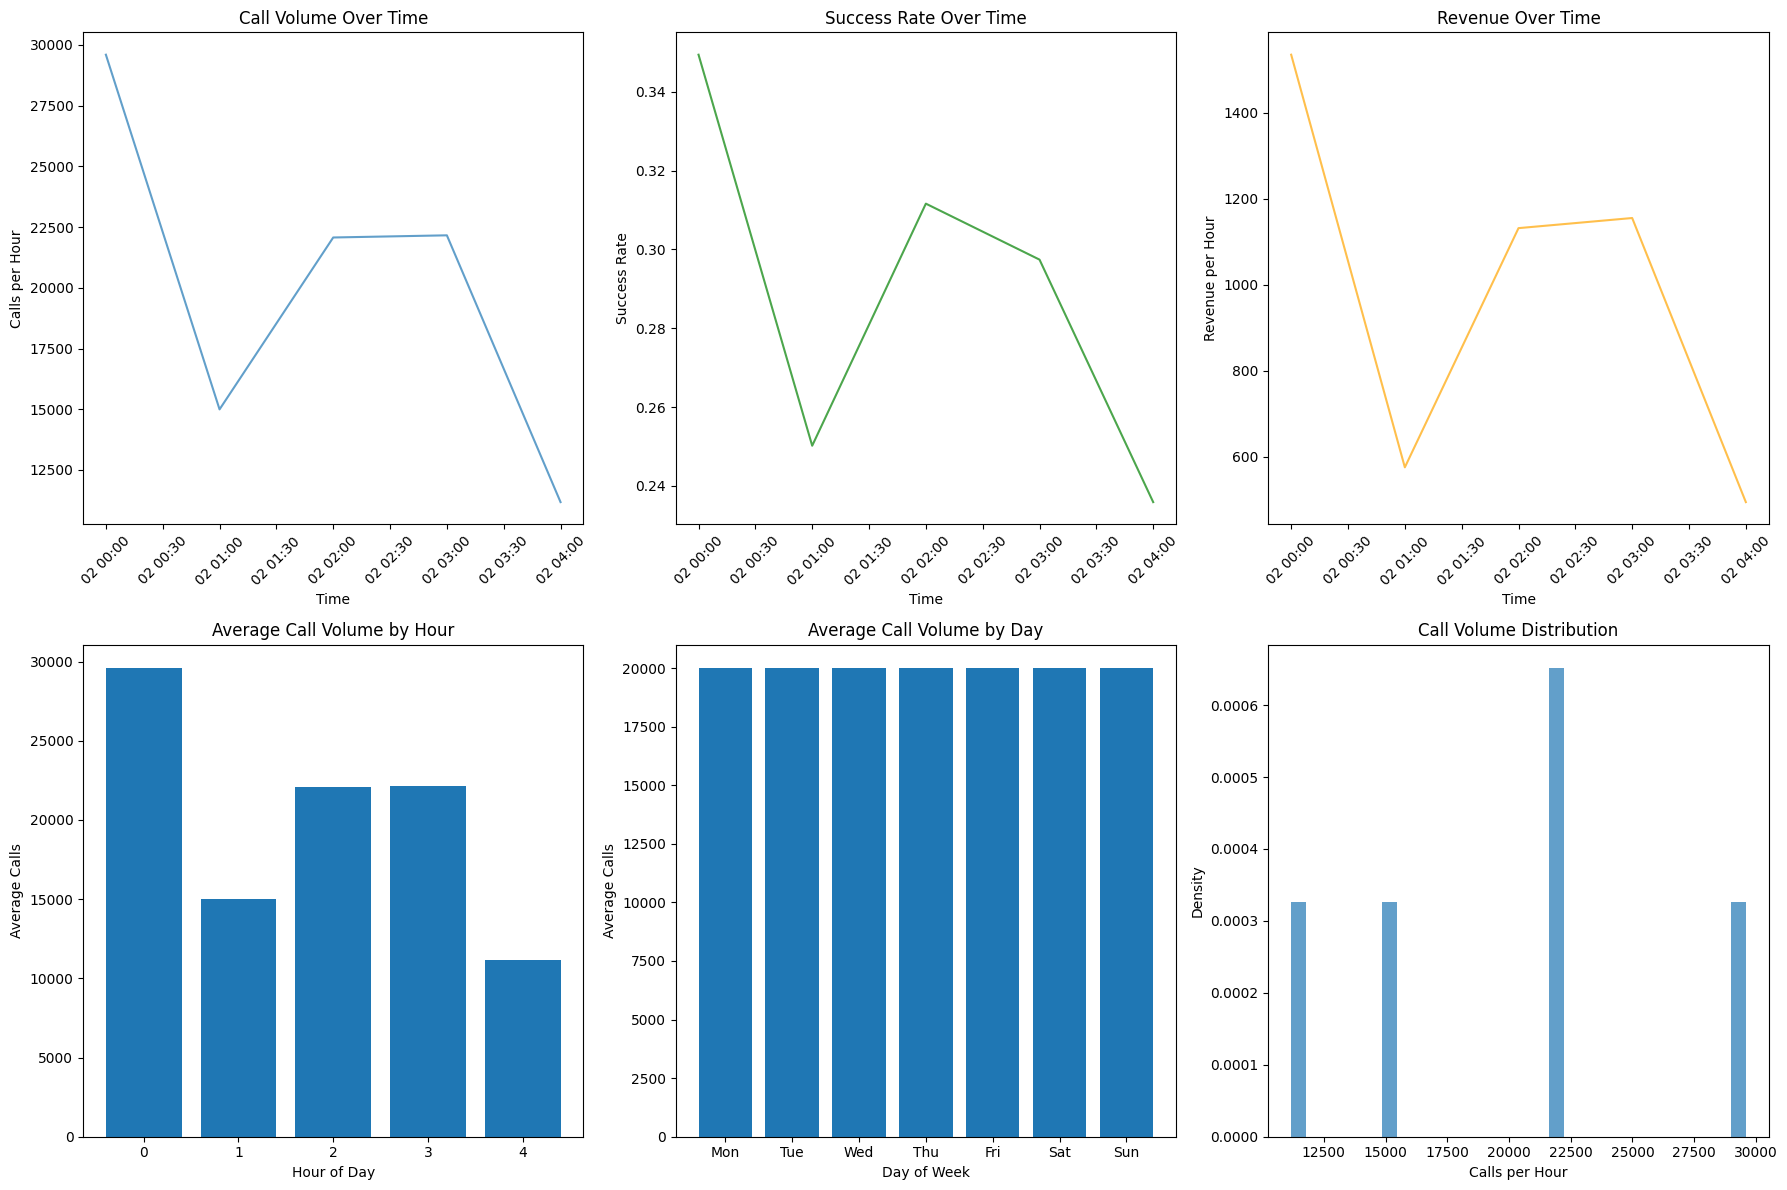

Data visualization completed!


In [10]:
# Cell 7 - Create visualizations to understand the data
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Call volume over time
axes[0,0].plot(call_features['timestamp'], call_features['call_volume'], alpha=0.7)
axes[0,0].set_title('Call Volume Over Time')
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Calls per Hour')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Success rate over time
axes[0,1].plot(call_features['timestamp'], call_features['success_rate'], alpha=0.7, color='green')
axes[0,1].set_title('Success Rate Over Time')
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Success Rate')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Revenue over time
axes[0,2].plot(call_features['timestamp'], call_features['total_revenue'], alpha=0.7, color='orange')
axes[0,2].set_title('Revenue Over Time')
axes[0,2].set_xlabel('Time')
axes[0,2].set_ylabel('Revenue per Hour')
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: Hourly patterns
hourly_pattern = call_features.groupby('hour')['call_volume'].mean()
axes[1,0].bar(hourly_pattern.index, hourly_pattern.values)
axes[1,0].set_title('Average Call Volume by Hour')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Average Calls')

# Plot 5: Daily patterns
daily_pattern = call_features.groupby('day_of_week')['call_volume'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1,1].bar(range(7), daily_pattern.values)
axes[1,1].set_title('Average Call Volume by Day')
axes[1,1].set_xlabel('Day of Week')
axes[1,1].set_ylabel('Average Calls')
axes[1,1].set_xticks(range(7))
axes[1,1].set_xticklabels(day_names)

# Plot 6: Distribution of key metrics
axes[1,2].hist(call_features['call_volume'], bins=30, alpha=0.7, density=True)
axes[1,2].set_title('Call Volume Distribution')
axes[1,2].set_xlabel('Calls per Hour')
axes[1,2].set_ylabel('Density')

plt.tight_layout()
plt.show()

print("Data visualization completed!")


In [18]:
# cell 8
def zscore_anomaly_detection(df, metrics, threshold= 1):
    """Z-score based anomaly detection"""
    print(f"Applying Z-Score detection with threshold: {threshold}")
    
    for metric in metrics:
        # Calculate Z-scores
        mean_val = df[metric].mean()
        std_val = df[metric].std()
        z_scores = np.abs((df[metric] - mean_val) / std_val)
        
        # Flag anomalies
        df[f'{metric}_zscore'] = z_scores
        df[f'{metric}_zscore_anomaly'] = (z_scores > threshold).astype(int)
        
        anomaly_count = df[f'{metric}_zscore_anomaly'].sum()
        print(f"  {metric}: {anomaly_count} anomalies ({anomaly_count/len(df)*100:.2f}%)")
    
    # Overall anomaly if any metric is anomalous
    zscore_cols = [col for col in df.columns if col.endswith('_zscore_anomaly')]
    df['zscore_anomaly_flag'] = df[zscore_cols].max(axis=1)
    
    total_anomalies = df['zscore_anomaly_flag'].sum()
    print(f"Total Z-Score anomalies: {total_anomalies} ({total_anomalies/len(df)*100:.2f}%)")
    
    return df

# Apply Z-Score detection
metrics_for_zscore = ['call_volume', 'success_rate', 'total_revenue', 'avg_duration']
call_features = zscore_anomaly_detection(call_features, metrics_for_zscore)

print("\n=== Z-SCORE DETECTION COMPLETED ===")


Applying Z-Score detection with threshold: 1
  call_volume: 2 anomalies (40.00%)
  success_rate: 2 anomalies (40.00%)
  total_revenue: 2 anomalies (40.00%)
  avg_duration: 1 anomalies (20.00%)
Total Z-Score anomalies: 2 (40.00%)

=== Z-SCORE DETECTION COMPLETED ===


In [19]:
# cell 9
def isolation_forest_detection(df, features, contamination=0.1):
    """Isolation Forest anomaly detection"""
    print(f"Applying Isolation Forest with contamination: {contamination}")
    
    # Prepare features
    X = df[features].fillna(0)
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply Isolation Forest
    iso_forest = IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)
    anomaly_labels = iso_forest.fit_predict(X_scaled)
    
    # Add results to dataframe
    df['isolation_forest_anomaly'] = (anomaly_labels == -1).astype(int)
    df['isolation_forest_score'] = iso_forest.decision_function(X_scaled)
    
    anomaly_count = df['isolation_forest_anomaly'].sum()
    print(f"Isolation Forest anomalies: {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")
    
    return df, iso_forest, scaler

# Define features for Isolation Forest
isolation_features = [
    'call_volume', 'avg_duration', 'success_rate', 'total_revenue',
    'call_volume_rolling_mean_24h', 'success_rate_rolling_std_24h',
    'call_volume_vs_hourly_baseline', 'success_rate_vs_hourly_baseline',
    'hour', 'day_of_week', 'is_weekend'
]

# Apply Isolation Forest
call_features, iso_model, scaler = isolation_forest_detection(call_features, isolation_features)

print("=== ISOLATION FOREST DETECTION COMPLETED ===")


Applying Isolation Forest with contamination: 0.1
Isolation Forest anomalies: 1 (20.00%)
=== ISOLATION FOREST DETECTION COMPLETED ===


In [20]:
# cell 10
def autoencoder_detection(df, features, threshold_percentile=95):
    """Simple autoencoder-style anomaly detection using MLPRegressor"""
    print(f"Applying Autoencoder detection with {threshold_percentile}th percentile threshold")
    
    X = df[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train autoencoder (using MLPRegressor as approximation)
    hidden_size = max(len(features)//2, 3)  # Ensure minimum hidden size
    autoencoder = MLPRegressor(
        hidden_layer_sizes=(hidden_size,), 
        max_iter=1000, 
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    
    try:
        autoencoder.fit(X_scaled, X_scaled)
        
        # Predict and calculate reconstruction error
        X_pred = autoencoder.predict(X_scaled)
        reconstruction_error = np.mean((X_scaled - X_pred) ** 2, axis=1)
        
        # Set threshold at specified percentile
        threshold = np.percentile(reconstruction_error, threshold_percentile)
        df['autoencoder_anomaly'] = (reconstruction_error > threshold).astype(int)
        df['reconstruction_error'] = reconstruction_error
        
        anomaly_count = df['autoencoder_anomaly'].sum()
        print(f"Autoencoder anomalies: {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")
        print(f"Reconstruction error threshold: {threshold:.6f}")
        
        return df, autoencoder
    
    except Exception as e:
        print(f"Autoencoder training failed: {e}")
        df['autoencoder_anomaly'] = 0
        df['reconstruction_error'] = 0
        return df, None

# Apply Autoencoder detection
autoencoder_features = isolation_features  # Use same features as Isolation Forest
call_features, ae_model = autoencoder_detection(call_features, autoencoder_features)

print("=== AUTOENCODER DETECTION COMPLETED ===")


Applying Autoencoder detection with 95th percentile threshold
Autoencoder anomalies: 1 (20.00%)
Reconstruction error threshold: 2.064002
=== AUTOENCODER DETECTION COMPLETED ===


In [21]:
#cell 11
def analyze_anomalies(df):
    """Analyze and combine anomaly detection results"""
    total_records = len(df)
    
    zscore_anomalies = df['zscore_anomaly_flag'].sum()
    isolation_anomalies = df['isolation_forest_anomaly'].sum()
    autoencoder_anomalies = df['autoencoder_anomaly'].sum()
    
    print("=== COMPREHENSIVE ANOMALY DETECTION RESULTS ===")
    print(f"Total records: {total_records:,}")
    print(f"Z-Score anomalies: {zscore_anomalies:,} ({zscore_anomalies/total_records*100:.2f}%)")
    print(f"Isolation Forest anomalies: {isolation_anomalies:,} ({isolation_anomalies/total_records*100:.2f}%)")
    print(f"Autoencoder anomalies: {autoencoder_anomalies:,} ({autoencoder_anomalies/total_records*100:.2f}%)")
    
    # Combined anomalies (any method detects)
    df['any_anomaly'] = ((df['zscore_anomaly_flag'] == 1) | 
                        (df['isolation_forest_anomaly'] == 1) | 
                        (df['autoencoder_anomaly'] == 1)).astype(int)
    
    # Consensus anomalies (multiple methods agree)
    df['consensus_anomaly'] = ((df['zscore_anomaly_flag'] + 
                              df['isolation_forest_anomaly'] + 
                              df['autoencoder_anomaly']) >= 2).astype(int)
    
    combined_anomalies = df['any_anomaly'].sum()
    consensus_anomalies = df['consensus_anomaly'].sum()
    
    print(f"Combined anomalies (any method): {combined_anomalies:,} ({combined_anomalies/total_records*100:.2f}%)")
    print(f"Consensus anomalies (2+ methods): {consensus_anomalies:,} ({consensus_anomalies/total_records*100:.2f}%)")
    
    # Method overlap analysis
    print("\n=== METHOD OVERLAP ANALYSIS ===")
    overlap_matrix = pd.crosstab(
        [df['zscore_anomaly_flag'], df['isolation_forest_anomaly']], 
        df['autoencoder_anomaly'], 
        margins=True
    )
    print(overlap_matrix)
    
    return df

# Analyze results
call_features = analyze_anomalies(call_features)


=== COMPREHENSIVE ANOMALY DETECTION RESULTS ===
Total records: 5
Z-Score anomalies: 2 (40.00%)
Isolation Forest anomalies: 1 (20.00%)
Autoencoder anomalies: 1 (20.00%)
Combined anomalies (any method): 2 (40.00%)
Consensus anomalies (2+ methods): 1 (20.00%)

=== METHOD OVERLAP ANALYSIS ===
autoencoder_anomaly                           0  1  All
zscore_anomaly_flag isolation_forest_anomaly           
0                   0                         3  0    3
1                   0                         1  0    1
                    1                         0  1    1
All                                           4  1    5


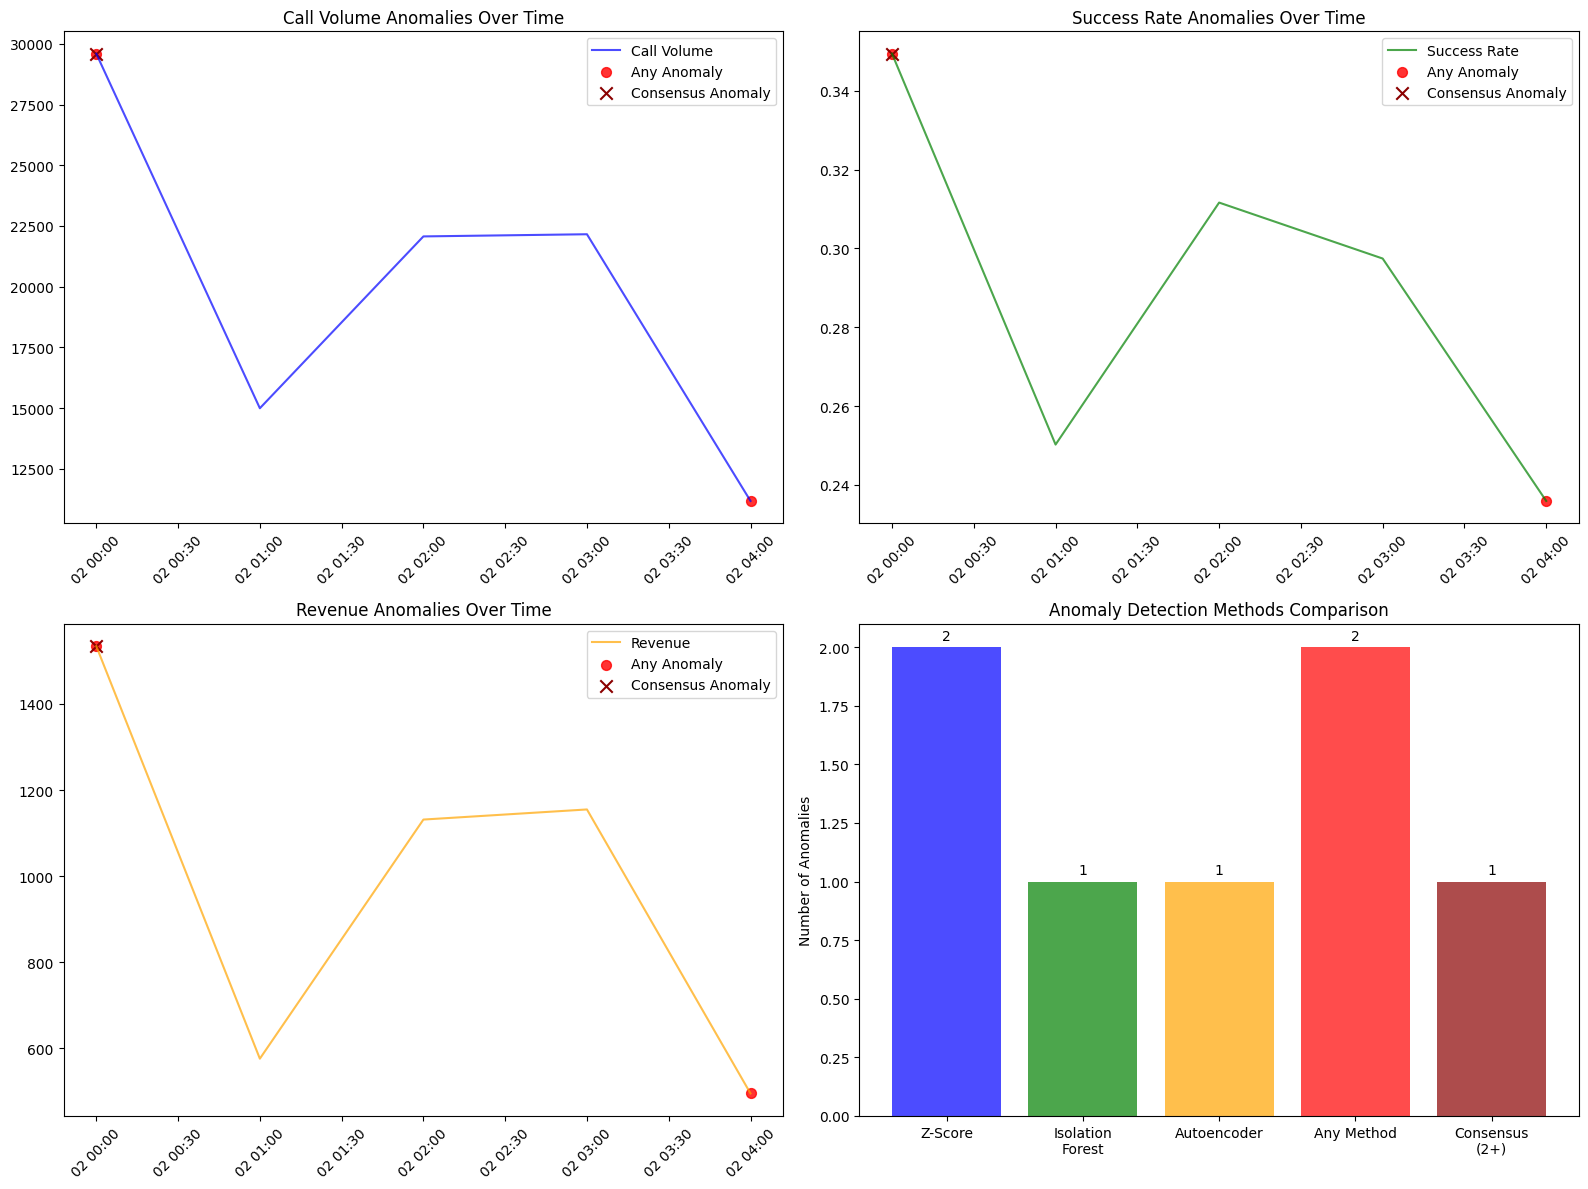

Anomaly visualization completed!


In [22]:
# cell 12 Create comprehensive anomaly visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get anomaly points for plotting
anomaly_points = call_features[call_features['any_anomaly'] == 1]
consensus_points = call_features[call_features['consensus_anomaly'] == 1]

# Plot 1: Call volume with anomalies
axes[0,0].plot(call_features['timestamp'], call_features['call_volume'], 
               alpha=0.7, label='Call Volume', color='blue')
axes[0,0].scatter(anomaly_points['timestamp'], anomaly_points['call_volume'], 
                  color='red', s=50, label='Any Anomaly', alpha=0.8)
axes[0,0].scatter(consensus_points['timestamp'], consensus_points['call_volume'], 
                  color='darkred', s=80, label='Consensus Anomaly', alpha=1.0, marker='x')
axes[0,0].set_title('Call Volume Anomalies Over Time')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Success rate with anomalies
axes[0,1].plot(call_features['timestamp'], call_features['success_rate'], 
               alpha=0.7, label='Success Rate', color='green')
axes[0,1].scatter(anomaly_points['timestamp'], anomaly_points['success_rate'], 
                  color='red', s=50, label='Any Anomaly', alpha=0.8)
axes[0,1].scatter(consensus_points['timestamp'], consensus_points['success_rate'], 
                  color='darkred', s=80, label='Consensus Anomaly', alpha=1.0, marker='x')
axes[0,1].set_title('Success Rate Anomalies Over Time')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Revenue anomalies
axes[1,0].plot(call_features['timestamp'], call_features['total_revenue'], 
               alpha=0.7, label='Revenue', color='orange')
axes[1,0].scatter(anomaly_points['timestamp'], anomaly_points['total_revenue'], 
                  color='red', s=50, label='Any Anomaly', alpha=0.8)
axes[1,0].scatter(consensus_points['timestamp'], consensus_points['total_revenue'], 
                  color='darkred', s=80, label='Consensus Anomaly', alpha=1.0, marker='x')
axes[1,0].set_title('Revenue Anomalies Over Time')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Method comparison
methods = ['Z-Score', 'Isolation\nForest', 'Autoencoder', 'Any Method', 'Consensus\n(2+)']
counts = [
    call_features['zscore_anomaly_flag'].sum(),
    call_features['isolation_forest_anomaly'].sum(),
    call_features['autoencoder_anomaly'].sum(),
    call_features['any_anomaly'].sum(),
    call_features['consensus_anomaly'].sum()
]
colors = ['blue', 'green', 'orange', 'red', 'darkred']
bars = axes[1,1].bar(methods, counts, color=colors, alpha=0.7)
axes[1,1].set_title('Anomaly Detection Methods Comparison')
axes[1,1].set_ylabel('Number of Anomalies')

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                   f'{count}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Anomaly visualization completed!")


In [23]:
#cell 13
def generate_anomaly_report(df):
    """Generate detailed anomaly report"""
    anomalies = df[df['any_anomaly'] == 1].copy()
    consensus_anomalies = df[df['consensus_anomaly'] == 1].copy()
    
    print("=== DETAILED ANOMALY REPORT ===")
    
    if len(anomalies) > 0:
        print(f"\n📊 ANOMALY SUMMARY:")
        print(f"Total anomalous time periods: {len(anomalies)}")
        print(f"Consensus anomalies: {len(consensus_anomalies)}")
        
        print(f"\n⏰ TEMPORAL PATTERNS:")
        print(f"Most anomalous hour: {anomalies['hour'].mode().iloc[0] if len(anomalies) > 0 else 'N/A'}")
        print(f"Most anomalous day: {anomalies['day_of_week'].mode().iloc[0] if len(anomalies) > 0 else 'N/A'}")
        print(f"Weekend anomalies: {anomalies['is_weekend'].sum()}/{len(anomalies)} ({anomalies['is_weekend'].mean()*100:.1f}%)")
        
        print(f"\n📈 SEVERITY ANALYSIS:")
        severe_anomalies = anomalies[
            (anomalies['call_volume_zscore'] > 4) | 
            (anomalies['success_rate'] < 0.5) | 
            (anomalies['isolation_forest_score'] < -0.5)
        ]
        print(f"Severe anomalies: {len(severe_anomalies)} ({len(severe_anomalies)/len(anomalies)*100:.1f}% of anomalies)")
        
        print(f"\n🔍 TOP 10 MOST SEVERE ANOMALIES:")
        # Sort by multiple criteria for severity
        anomalies['severity_score'] = (
            anomalies['call_volume_zscore'].fillna(0) * 0.3 +
            (1 - anomalies['success_rate']) * 0.4 +
            np.abs(anomalies['isolation_forest_score'].fillna(0)) * 0.3
        )
        
        top_anomalies = anomalies.nlargest(10, 'severity_score')[
            ['timestamp', 'call_volume', 'success_rate', 'total_revenue', 'severity_score',
             'zscore_anomaly_flag', 'isolation_forest_anomaly', 'autoencoder_anomaly']
        ]
        
        print(top_anomalies.to_string(index=False, float_format='%.2f'))
        
        # Business impact analysis
        print(f"\n💰 BUSINESS IMPACT:")
        normal_revenue = df[df['any_anomaly'] == 0]['total_revenue'].mean()
        anomaly_revenue = anomalies['total_revenue'].mean()
        revenue_impact = ((anomaly_revenue - normal_revenue) / normal_revenue) * 100
        
        print(f"Average revenue (normal): ${normal_revenue:.2f}")
        print(f"Average revenue (anomalies): ${anomaly_revenue:.2f}")
        print(f"Revenue impact: {revenue_impact:+.1f}%")
        
    else:
        print("No anomalies detected!")
    
    return anomalies

# Generate report
detected_anomalies = generate_anomaly_report(call_features)


=== DETAILED ANOMALY REPORT ===

📊 ANOMALY SUMMARY:
Total anomalous time periods: 2
Consensus anomalies: 1

⏰ TEMPORAL PATTERNS:
Most anomalous hour: 0
Most anomalous day: 6
Weekend anomalies: 2/2 (100.0%)

📈 SEVERITY ANALYSIS:
Severe anomalies: 2 (100.0% of anomalies)

🔍 TOP 10 MOST SEVERE ANOMALIES:
          timestamp  call_volume  success_rate  total_revenue  severity_score  zscore_anomaly_flag  isolation_forest_anomaly  autoencoder_anomaly
2020-02-02 04:00:00        11178          0.24         494.79            0.70                    1                         0                    0
2020-02-02 00:00:00        29595          0.35        1534.33            0.68                    1                         1                    1

💰 BUSINESS IMPACT:
Average revenue (normal): $953.95
Average revenue (anomalies): $1014.56
Revenue impact: +6.4%


In [24]:
# cell 14
# Save results to files
print("=== SAVING RESULTS ===")

# 1. Save complete dataset with anomaly flags
output_file = 'cdr_with_anomaly_detection.csv'
call_features.to_csv(output_file, index=False)
print(f"✅ Complete dataset saved: {output_file}")

# 2. Save anomalies only
if len(detected_anomalies) > 0:
    anomaly_file = 'detected_anomalies.csv'
    detected_anomalies.to_csv(anomaly_file, index=False)
    print(f"✅ Anomalies saved: {anomaly_file}")

# 3. Create summary report
summary_stats = {
    'Metric': [
        'Total Time Periods',
        'Z-Score Anomalies', 
        'Isolation Forest Anomalies',
        'Autoencoder Anomalies',
        'Combined Anomalies',
        'Consensus Anomalies',
        'Average Call Volume',
        'Average Success Rate',
        'Total Revenue',
        'Analysis Period'
    ],
    'Value': [
        len(call_features),
        call_features['zscore_anomaly_flag'].sum(),
        call_features['isolation_forest_anomaly'].sum(), 
        call_features['autoencoder_anomaly'].sum(),
        call_features['any_anomaly'].sum(),
        call_features['consensus_anomaly'].sum(),
        f"{call_features['call_volume'].mean():.1f}",
        f"{call_features['success_rate'].mean()*100:.1f}%",
        f"${call_features['total_revenue'].sum():,.2f}",
        f"{call_features['timestamp'].min()} to {call_features['timestamp'].max()}"
    ]
}

summary_df = pd.DataFrame(summary_stats)
summary_file = 'anomaly_detection_summary.csv'
summary_df.to_csv(summary_file, index=False)
print(f"✅ Summary report saved: {summary_file}")

# Display final summary
print(f"\n=== FINAL SUMMARY ===")
print(summary_df.to_string(index=False))

print(f"\n🎉 ANOMALY DETECTION COMPLETED SUCCESSFULLY!")
print(f"📁 Files created:")
print(f"   - {output_file}")
print(f"   - {anomaly_file}")
print(f"   - {summary_file}")


=== SAVING RESULTS ===
✅ Complete dataset saved: cdr_with_anomaly_detection.csv
✅ Anomalies saved: detected_anomalies.csv
✅ Summary report saved: anomaly_detection_summary.csv

=== FINAL SUMMARY ===
                    Metric                                      Value
        Total Time Periods                                          5
         Z-Score Anomalies                                          2
Isolation Forest Anomalies                                          1
     Autoencoder Anomalies                                          1
        Combined Anomalies                                          2
       Consensus Anomalies                                          1
       Average Call Volume                                    19999.8
      Average Success Rate                                      28.9%
             Total Revenue                                  $4,890.98
           Analysis Period 2020-02-02 00:00:00 to 2020-02-02 04:00:00

🎉 ANOMALY DETECTION COMPLETED 

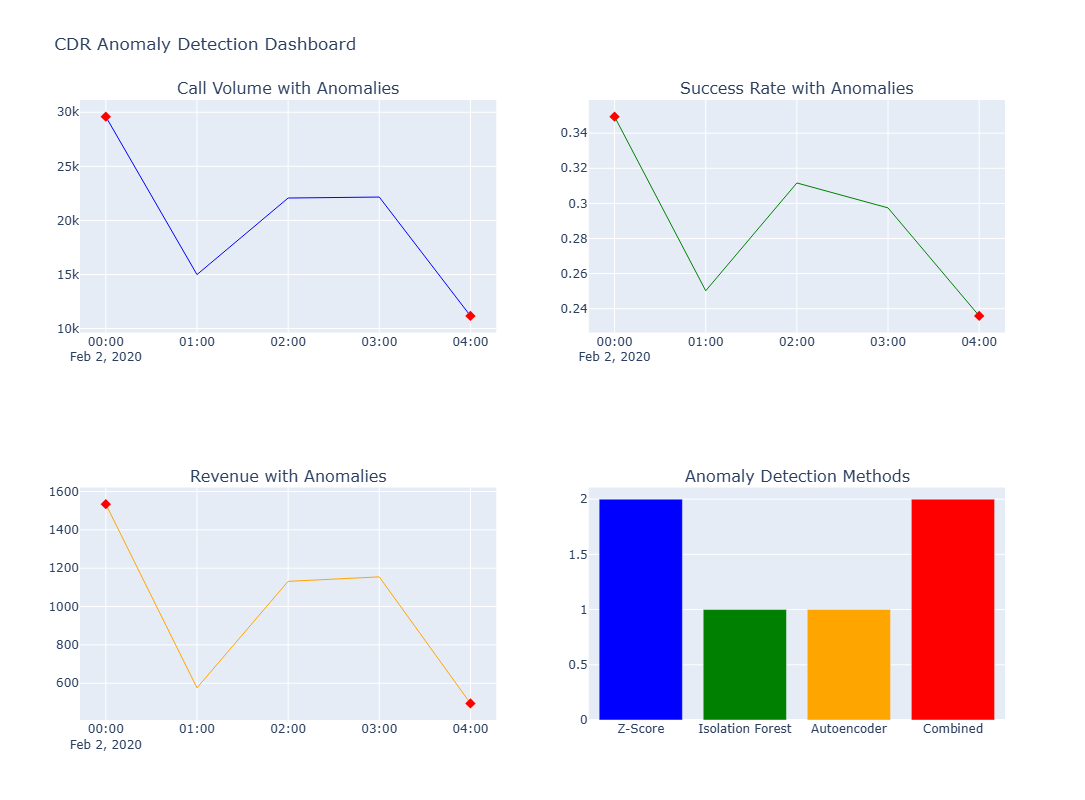

Interactive dashboard created!


In [25]:
# cell 15 Create interactive visualization using Plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create interactive dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Call Volume with Anomalies', 'Success Rate with Anomalies',
                   'Revenue with Anomalies', 'Anomaly Detection Methods'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"type": "bar"}]]
)

# Plot 1: Call volume
fig.add_trace(
    go.Scatter(x=call_features['timestamp'], y=call_features['call_volume'],
               mode='lines', name='Call Volume', line=dict(color='blue', width=1)),
    row=1, col=1
)

anomaly_points = call_features[call_features['any_anomaly'] == 1]
fig.add_trace(
    go.Scatter(x=anomaly_points['timestamp'], y=anomaly_points['call_volume'],
               mode='markers', name='Anomalies', 
               marker=dict(color='red', size=8, symbol='diamond')),
    row=1, col=1
)

# Plot 2: Success rate
fig.add_trace(
    go.Scatter(x=call_features['timestamp'], y=call_features['success_rate'],
               mode='lines', name='Success Rate', line=dict(color='green', width=1)),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(x=anomaly_points['timestamp'], y=anomaly_points['success_rate'],
               mode='markers', name='Anomalies', 
               marker=dict(color='red', size=8, symbol='diamond')),
    row=1, col=2
)

# Plot 3: Revenue
fig.add_trace(
    go.Scatter(x=call_features['timestamp'], y=call_features['total_revenue'],
               mode='lines', name='Revenue', line=dict(color='orange', width=1)),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=anomaly_points['timestamp'], y=anomaly_points['total_revenue'],
               mode='markers', name='Anomalies', 
               marker=dict(color='red', size=8, symbol='diamond')),
    row=2, col=1
)

# Plot 4: Method comparison
methods = ['Z-Score', 'Isolation Forest', 'Autoencoder', 'Combined']
counts = [
    call_features['zscore_anomaly_flag'].sum(),
    call_features['isolation_forest_anomaly'].sum(),
    call_features['autoencoder_anomaly'].sum(),
    call_features['any_anomaly'].sum()
]

fig.add_trace(
    go.Bar(x=methods, y=counts, name='Anomaly Count',
           marker=dict(color=['blue', 'green', 'orange', 'red'])),
    row=2, col=2
)

# Update layout
fig.update_layout(
    height=800,
    title_text="CDR Anomaly Detection Dashboard",
    showlegend=False
)

fig.show()

print("Interactive dashboard created!")
